  
# Trabajo Práctico N 3 — Aprendizaje por Refuerzo 1


## CEIA - Cohorte 21Co2025
### Integrantes
- José Aviani - jose.aviani@gmail.com
- José Luis Diaz - diazjoseluis@gmail.com 
- Ricardo Silvera - rsilvera@thalu.com.ar
---
**Algoritmos:** SARSA (on-policy) y Q-Learning (off-policy) con espacio de estados discretizado  
**Entorno:** `LunarLander-v3` (Gymnasium / Box2D)  



## Instalación de Dependencias

In [1]:
%pip install "gymnasium[box2d]" numpy matplotlib imageio --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image as IPImage

SEED = 42
np.random.seed(SEED)

print(f"Gymnasium version: {gym.__version__}")
print(f"imageio version:   {imageio.__version__}")

Gymnasium version: 1.3.0
imageio version:   2.37.3


## Exploración del Entorno

In [2]:
env = gym.make("LunarLander-v3")

print("=== Información del entorno ===")
print(f"Espacio de observación: {env.observation_space}")
print(f"  Límites inferiores: {env.observation_space.low}")
print(f"  Límites superiores: {env.observation_space.high}")
print(f"Espacio de acciones:    {env.action_space}  ({env.action_space.n} acciones discretas)")
print()
print("Acciones:")
for i, a in enumerate(["No hacer nada", "Propulsor izquierdo", "Propulsor principal (↑)", "Propulsor derecho"]):
    print(f"  {i}: {a}")
print()

# Episodio de muestra con política aleatoria
rewards_random_baseline = []
for ep in range(50):
    obs, _ = env.reset(seed=SEED + ep)
    total, done = 0.0, False
    while not done:
        action = env.action_space.sample()
        obs, r, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total += r
    rewards_random_baseline.append(total)

print(f"Política aleatoria (50 episodios):")
print(f"  Media:  {np.mean(rewards_random_baseline):.1f}")
print(f"  Rango:  [{min(rewards_random_baseline):.1f}, {max(rewards_random_baseline):.1f}]")

env.close()

=== Información del entorno ===
Espacio de observación: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  Límites inferiores: [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
  Límites superiores: [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]
Espacio de acciones:    Discrete(4)  (4 acciones discretas)

Acciones:
  0: No hacer nada
  1: Propulsor izquierdo
  2: Propulsor principal (↑)
  3: Propulsor derecho

Política aleatoria (50 episodios):
  Media:  -171.1
  Rango:  [-526.2, 108.0]


## Discretización del Espacio de Estados


In [ ]:
# Discretización no uniforme: más bins para las variables más críticas.
# y (altura) y vy (velocidad vertical) son clave para el propulsor principal.
# vx (vel. horizontal) y theta (ángulo) son clave para los propulsores laterales.
BINS_PER_VAR = [3, 5, 3,  6,  4,  3]
#               x  y  vx  vy  θ   ω

OBS_LOW  = np.array([-1.5, -0.1, -3.0, -3.0, -0.5, -3.0])
OBS_HIGH = np.array([ 1.5,  1.8,  3.0,  3.0,  0.5,  3.0])

BINS = [
    np.linspace(OBS_LOW[i], OBS_HIGH[i], BINS_PER_VAR[i] + 1)[1:-1]
    for i in range(6)
]

# Forma del espacio discreto: 6 continuas + 2 binarias (contacto)
SHAPE     = tuple(BINS_PER_VAR) + (2, 2)
N_STATES  = int(np.prod(SHAPE))
N_ACTIONS = 4

def discretize(obs):
    """
    Convierte una observación continua (8 valores) en un índice entero.

    Los primeros 6 valores son continuos (posición, velocidad, ángulo).
    Los últimos 2 son binarios (contacto patas izquierda/derecha).
    """
    idx_cont = tuple(
        int(np.clip(np.digitize(obs[i], BINS[i]), 0, BINS_PER_VAR[i] - 1))
        for i in range(6)
    )
    idx_contact = (int(obs[6]), int(obs[7]))
    return int(np.ravel_multi_index(idx_cont + idx_contact, SHAPE))


print(f"Bins por variable:             {BINS_PER_VAR}  (x, y, vx, vy, θ, ω)")
print(f"Dimensiones discretas:         {SHAPE}")
print(f"Total de estados:              {N_STATES:,}")
print(f"Tamaño de la Q-table:          {N_STATES:,} × {N_ACTIONS} = {N_STATES * N_ACTIONS:,} entradas")
print(f"Memoria aproximada (float64):  {N_STATES * N_ACTIONS * 8 / 1e6:.1f} MB")

# Verificación
env_test = gym.make("LunarLander-v3")
obs, _ = env_test.reset(seed=0)
print(f"\nEjemplo — obs:    {obs}")
print(f"           estado: {discretize(obs)}")
env_test.close()

Bins por variable:             [3, 5, 3, 6, 4, 3]  (x, y, vx, vy, θ, ω)
Dimensiones discretas:         (3, 5, 3, 6, 4, 3, 2, 2)
Total de estados:              12,960
Tamaño de la Q-table:          12,960 × 4 = 51,840 entradas
Memoria aproximada (float64):  0.4 MB

Ejemplo — obs:    [ 0.00570612  1.3990337   0.5779653  -0.5282997  -0.0066053  -0.13091765
  0.          0.        ]
           estado: 7312


## Implementación de SARSA y Q-Learning

In [9]:
def shaping_potential(obs):
    """Potencial para reward shaping (Ng et al. 1999): F(s,s') = gamma*Phi(s') - Phi(s).
    Guia al agente hacia: pad de aterrizaje, baja velocidad, posicion vertical.
    """
    x, y, vx, vy, theta = obs[0], obs[1], obs[2], obs[3], obs[4]
    return (
        -1.0 * np.sqrt(x**2 + y**2)    # distancia al pad -> menor = mejor
        -0.5 * np.sqrt(vx**2 + vy**2)  # velocidad total -> mas lento = mejor
        -0.3 * abs(theta)               # inclinacion -> mas vertical = mejor
    )


def epsilon_greedy(Q, state, n_actions, epsilon):
    """Selecciona accion con politica epsilon-greedy."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[state]))


def train_sarsa(
    n_episodes    = 80000,
    alpha         = 0.15,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.9995,
    seed          = SEED,
    verbose       = True,
):
    """SARSA tabular con reward shaping potencial.
    r_shaped = r + gamma*Phi(s') - Phi(s)
    rewards_log registra recompensa real (sin shaping) por episodio.
    """
    env     = gym.make("LunarLander-v3")
    Q       = np.full((N_STATES, N_ACTIONS), 5.0)  # inicializacion optimista
    visited = np.zeros(N_STATES, dtype=bool)

    rewards_log = []
    epsilon     = epsilon_start

    for episode in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode)
        state  = discretize(obs)
        action = epsilon_greedy(Q, state, N_ACTIONS, epsilon)
        phi    = shaping_potential(obs)

        total_reward = 0.0
        done         = False

        while not done:
            visited[state] = True
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done        = terminated or truncated
            next_state  = discretize(next_obs)
            next_action = epsilon_greedy(Q, next_state, N_ACTIONS, epsilon)
            next_phi    = shaping_potential(next_obs)

            # Reward shaping potencial
            shaped = reward + gamma * next_phi * (not done) - phi
            # Actualizacion SARSA (on-policy)
            td_target = shaped + gamma * Q[next_state, next_action] * (not done)
            Q[state, action] += alpha * (td_target - Q[state, action])

            state  = next_state
            action = next_action
            phi    = next_phi
            total_reward += reward  # log sin shaping

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards_log.append(total_reward)

        if verbose and (episode + 1) % 500 == 0:
            pct_visited = visited.sum() / N_STATES * 100
            print(f"  [SARSA]      Ep {episode+1:>6} | "
                  f"Media(ult. 100): {np.mean(rewards_log[-100:]):>7.1f} | "
                  f"e={epsilon:.4f} | "
                  f"Estados visitados: {pct_visited:.2f}%")

    env.close()
    return Q, rewards_log


def train_qlearning(
    n_episodes    = 80000,
    alpha         = 0.15,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.9995,
    seed          = SEED,
    verbose       = True,
):
    """Q-Learning tabular con reward shaping potencial.
    r_shaped = r + gamma*Phi(s') - Phi(s)
    rewards_log registra recompensa real (sin shaping) por episodio.
    """
    env     = gym.make("LunarLander-v3")
    Q       = np.full((N_STATES, N_ACTIONS), 5.0)  # inicializacion optimista
    visited = np.zeros(N_STATES, dtype=bool)

    rewards_log = []
    epsilon     = epsilon_start

    for episode in range(n_episodes):
        obs, _ = env.reset(seed=seed + episode)
        state  = discretize(obs)
        phi    = shaping_potential(obs)

        total_reward = 0.0
        done         = False

        while not done:
            visited[state] = True
            action = epsilon_greedy(Q, state, N_ACTIONS, epsilon)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done       = terminated or truncated
            next_state = discretize(next_obs)
            next_phi   = shaping_potential(next_obs)

            # Reward shaping potencial
            shaped = reward + gamma * next_phi * (not done) - phi
            # Actualizacion Q-Learning (off-policy)
            td_target = shaped + gamma * np.max(Q[next_state]) * (not done)
            Q[state, action] += alpha * (td_target - Q[state, action])

            state        = next_state
            phi          = next_phi
            total_reward += reward  # log sin shaping

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        rewards_log.append(total_reward)

        if verbose and (episode + 1) % 500 == 0:
            pct_visited = visited.sum() / N_STATES * 100
            print(f"  [Q-Learning] Ep {episode+1:>6} | "
                  f"Media(ult. 100): {np.mean(rewards_log[-100:]):>7.1f} | "
                  f"e={epsilon:.4f} | "
                  f"Estados visitados: {pct_visited:.2f}%")

    env.close()
    return Q, rewards_log

## Entrenamiento

### SARSA

In [10]:
N_EPISODES    = 200000
ALPHA         = 0.1
GAMMA         = 0.99
EPSILON_START = 1.0
EPSILON_END   = 0.01
EPSILON_DECAY = 0.9999

hyperparams = dict(
    n_episodes    = N_EPISODES,
    alpha         = ALPHA,
    gamma         = GAMMA,
    epsilon_start = EPSILON_START,
    epsilon_end   = EPSILON_END,
    epsilon_decay = EPSILON_DECAY,
    seed          = SEED,
    verbose       = True,
)

print("=" * 55)
print("Entrenando SARSA en LunarLander-v3...")
print("=" * 55)
Q_sarsa, rewards_sarsa = train_sarsa(**hyperparams)

Entrenando SARSA en LunarLander-v3...
  [SARSA]      Ep    500 | Media(ult. 100):  -184.8 | e=0.9512 | Estados visitados: 2.26%
  [SARSA]      Ep   1000 | Media(ult. 100):  -172.4 | e=0.9048 | Estados visitados: 2.73%
  [SARSA]      Ep   1500 | Media(ult. 100):  -179.0 | e=0.8607 | Estados visitados: 3.20%
  [SARSA]      Ep   2000 | Media(ult. 100):  -156.8 | e=0.8187 | Estados visitados: 3.53%
  [SARSA]      Ep   2500 | Media(ult. 100):  -151.5 | e=0.7788 | Estados visitados: 3.80%
  [SARSA]      Ep   3000 | Media(ult. 100):  -151.1 | e=0.7408 | Estados visitados: 4.01%
  [SARSA]      Ep   3500 | Media(ult. 100):  -142.3 | e=0.7047 | Estados visitados: 4.23%
  [SARSA]      Ep   4000 | Media(ult. 100):  -141.8 | e=0.6703 | Estados visitados: 4.45%
  [SARSA]      Ep   4500 | Media(ult. 100):  -127.2 | e=0.6376 | Estados visitados: 4.63%
  [SARSA]      Ep   5000 | Media(ult. 100):  -125.6 | e=0.6065 | Estados visitados: 4.81%
  [SARSA]      Ep   5500 | Media(ult. 100):  -120.7 | e=0.5769

### Q-Lerning

In [16]:


hyperparams = dict(
    n_episodes    = N_EPISODES,
    alpha         = ALPHA,
    gamma         = GAMMA,
    epsilon_start = EPSILON_START,
    epsilon_end   = EPSILON_END,
    epsilon_decay = EPSILON_DECAY,
    seed          = SEED,
    verbose       = True,
)

print()
print("=" * 55)
print("Entrenando Q-Learning en LunarLander-v3...")
print("=" * 55)
Q_ql, rewards_ql = train_qlearning(**hyperparams)




Entrenando Q-Learning en LunarLander-v3...
  [Q-Learning] Ep    500 | Media(ult. 100):  -172.1 | e=0.9512 | Estados visitados: 2.15%
  [Q-Learning] Ep   1000 | Media(ult. 100):  -163.4 | e=0.9048 | Estados visitados: 2.62%
  [Q-Learning] Ep   1500 | Media(ult. 100):  -163.3 | e=0.8607 | Estados visitados: 2.93%
  [Q-Learning] Ep   2000 | Media(ult. 100):  -146.6 | e=0.8187 | Estados visitados: 3.35%
  [Q-Learning] Ep   2500 | Media(ult. 100):  -152.1 | e=0.7788 | Estados visitados: 3.56%
  [Q-Learning] Ep   3000 | Media(ult. 100):  -139.1 | e=0.7408 | Estados visitados: 3.83%
  [Q-Learning] Ep   3500 | Media(ult. 100):  -128.3 | e=0.7047 | Estados visitados: 4.09%
  [Q-Learning] Ep   4000 | Media(ult. 100):  -124.2 | e=0.6703 | Estados visitados: 4.40%
  [Q-Learning] Ep   4500 | Media(ult. 100):  -125.9 | e=0.6376 | Estados visitados: 4.65%
  [Q-Learning] Ep   5000 | Media(ult. 100):  -127.6 | e=0.6065 | Estados visitados: 4.81%
  [Q-Learning] Ep   5500 | Media(ult. 100):  -128.4 | e=

In [17]:
print("Entrenamiento terminado.")
print(f"SARSA     — media últimos 100 ep.: {np.mean(rewards_sarsa[-100:]):.1f}")
print(f"Q-Learning — media últimos 100 ep.: {np.mean(rewards_ql[-100:]):.1f}")

Entrenamiento terminado.
SARSA     — media últimos 100 ep.: -154.9
Q-Learning — media últimos 100 ep.: -98.4


## Curvas de Aprendizaje — Comparación SARSA vs Q-Learning

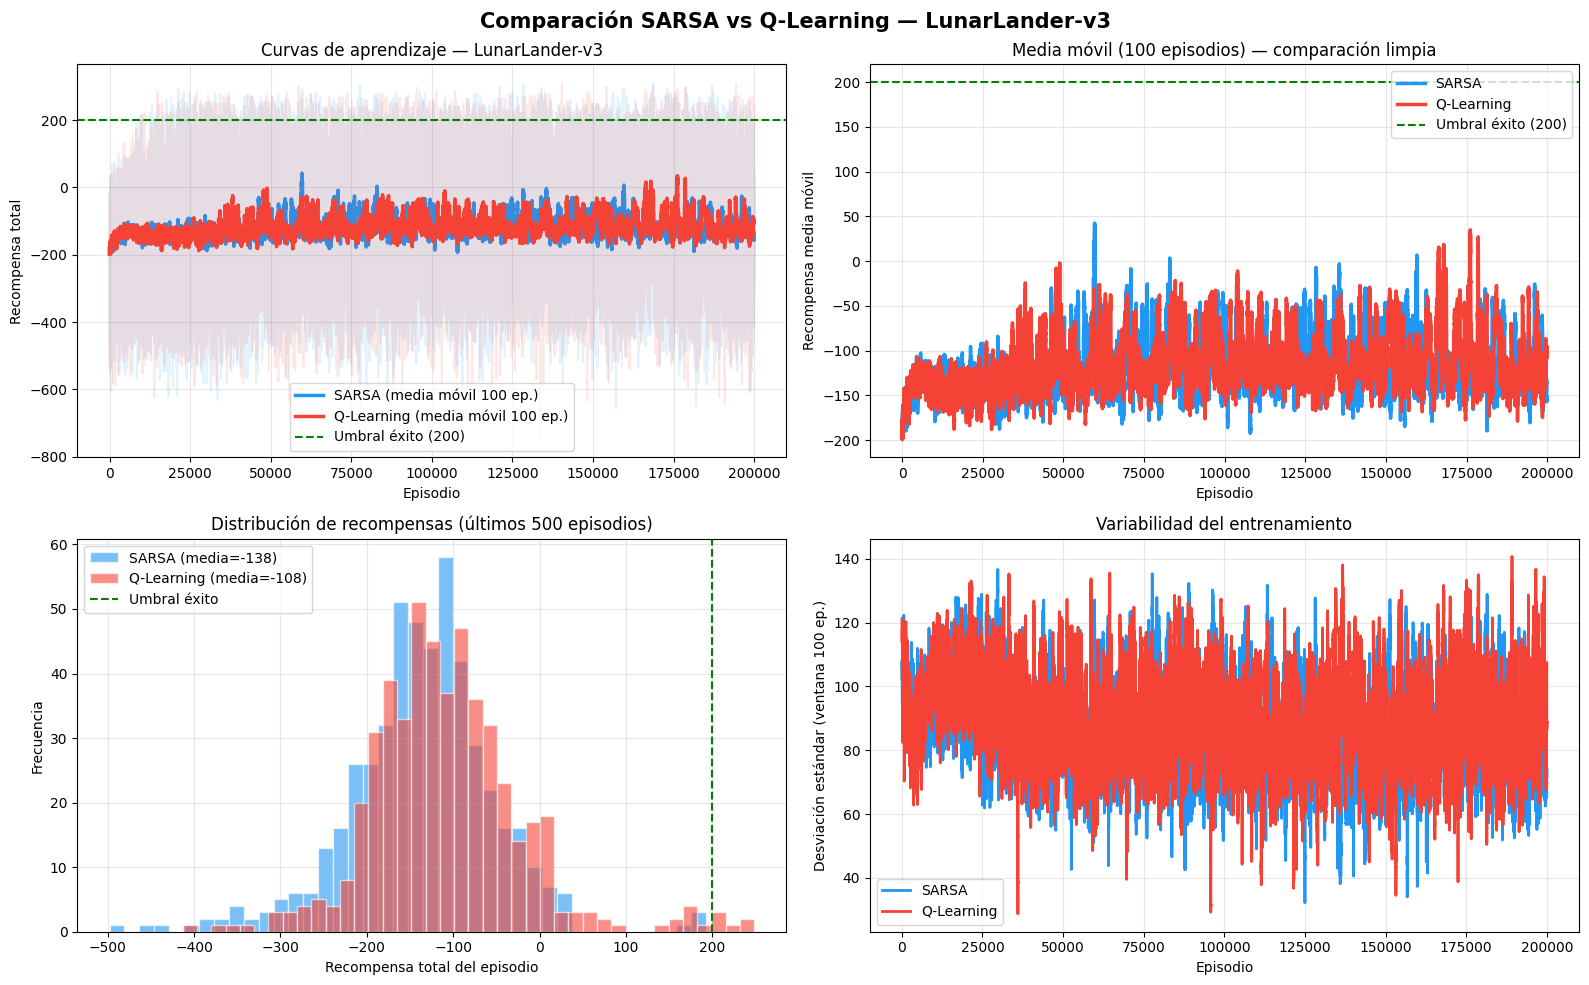

In [18]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window) / window, mode="valid")


COLOR_SARSA = "#2196F3"   # azul
COLOR_QL    = "#F44336"   # rojo
WINDOW      = 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ─── 1. Curvas brutas + media móvil ──────────────────────────────────────────
ax = axes[0, 0]
ax.plot(rewards_sarsa, alpha=0.12, color=COLOR_SARSA)
ax.plot(smooth(rewards_sarsa, WINDOW), color=COLOR_SARSA, linewidth=2.5,
        label=f"SARSA (media móvil {WINDOW} ep.)")
ax.plot(rewards_ql, alpha=0.12, color=COLOR_QL)
ax.plot(smooth(rewards_ql, WINDOW), color=COLOR_QL, linewidth=2.5,
        label=f"Q-Learning (media móvil {WINDOW} ep.)")
ax.axhline(y=200, color="green", linestyle="--", linewidth=1.5, label="Umbral éxito (200)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa total")
ax.set_title("Curvas de aprendizaje — LunarLander-v3")
ax.legend()
ax.grid(True, alpha=0.3)

# ─── 2. Media móvil solamente (más limpio) ───────────────────────────────────
ax = axes[0, 1]
ax.plot(smooth(rewards_sarsa, WINDOW), color=COLOR_SARSA, linewidth=2.5, label="SARSA")
ax.plot(smooth(rewards_ql,    WINDOW), color=COLOR_QL,    linewidth=2.5, label="Q-Learning")
ax.axhline(y=200, color="green", linestyle="--", linewidth=1.5, label="Umbral éxito (200)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa media móvil")
ax.set_title(f"Media móvil ({WINDOW} episodios) — comparación limpia")
ax.legend()
ax.grid(True, alpha=0.3)

# ─── 3. Distribución últimos 500 episodios ───────────────────────────────────
ax = axes[1, 0]
ax.hist(rewards_sarsa[-500:], bins=40, alpha=0.6, color=COLOR_SARSA, edgecolor="white",
        label=f"SARSA (media={np.mean(rewards_sarsa[-500:]):.0f})")
ax.hist(rewards_ql[-500:],    bins=40, alpha=0.6, color=COLOR_QL,    edgecolor="white",
        label=f"Q-Learning (media={np.mean(rewards_ql[-500:]):.0f})")
ax.axvline(x=200, color="green", linestyle="--", linewidth=1.5, label="Umbral éxito")
ax.set_xlabel("Recompensa total del episodio")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de recompensas (últimos 500 episodios)")
ax.legend()
ax.grid(True, alpha=0.3)

# ─── 4. Variabilidad: desviación estándar con ventana deslizante ─────────────
ax = axes[1, 1]
def rolling_std(data, window=100):
    stds = []
    for i in range(window, len(data) + 1):
        stds.append(np.std(data[i - window:i]))
    return stds

std_sarsa = rolling_std(rewards_sarsa, WINDOW)
std_ql    = rolling_std(rewards_ql,    WINDOW)
x_std     = np.arange(WINDOW, N_EPISODES + 1)

ax.plot(x_std, std_sarsa, color=COLOR_SARSA, linewidth=2, label="SARSA")
ax.plot(x_std, std_ql,    color=COLOR_QL,    linewidth=2, label="Q-Learning")
ax.set_xlabel("Episodio")
ax.set_ylabel("Desviación estándar (ventana 100 ep.)")
ax.set_title("Variabilidad del entrenamiento")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Comparación SARSA vs Q-Learning — LunarLander-v3", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Evaluación de las Políticas Aprendidas

Se evalúan ambas políticas en **modo greedy puro** (ε = 0) sobre 200 episodios con semillas distintas a las del entrenamiento → mide generalización real.

In [19]:
def evaluate_policy(Q, n_eval=200, greedy=True, seed=9000):
    """
    Evalúa una política sobre n_eval episodios.

    Args:
        greedy: si True usa argmax(Q), si False usa política aleatoria

    Returns:
        lista de recompensas totales por episodio
    """
    env_eval = gym.make("LunarLander-v3")
    rewards  = []
    for ep in range(n_eval):
        obs, _ = env_eval.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            if greedy:
                state  = discretize(obs)
                action = int(np.argmax(Q[state]))
            else:
                action = env_eval.action_space.sample()
            obs, r, terminated, truncated, _ = env_eval.step(action)
            done   = terminated or truncated
            total += r
        rewards.append(total)
    env_eval.close()
    return rewards


print("Evaluando políticas (200 episodios cada una)...")
eval_sarsa  = evaluate_policy(Q_sarsa, greedy=True)
eval_ql     = evaluate_policy(Q_ql,    greedy=True)
eval_random = evaluate_policy(Q_sarsa, greedy=False)  # aleatoria como baseline

print(f"\n{'Política':<20} {'Media':>8} {'Mediana':>8} {'Max':>8} {'Min':>8} {'Tasa éxito (≥200)':>20}")
print("-" * 75)
for name, data in [("Aleatorio", eval_random), ("SARSA", eval_sarsa), ("Q-Learning", eval_ql)]:
    tasa = sum(r >= 200 for r in data) / len(data) * 100
    print(f"{name:<20} {np.mean(data):>8.1f} {np.median(data):>8.1f} "
          f"{max(data):>8.1f} {min(data):>8.1f} {tasa:>19.1f}%")

Evaluando políticas (200 episodios cada una)...

Política                Media  Mediana      Max      Min    Tasa éxito (≥200)
---------------------------------------------------------------------------
Aleatorio              -196.2   -162.0     83.5   -467.1                 0.0%
SARSA                  -150.2   -147.2    139.5   -554.8                 0.0%
Q-Learning             -100.8   -124.5    260.2   -289.3                 2.0%


/tmp/ipykernel_62178/3425845453.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


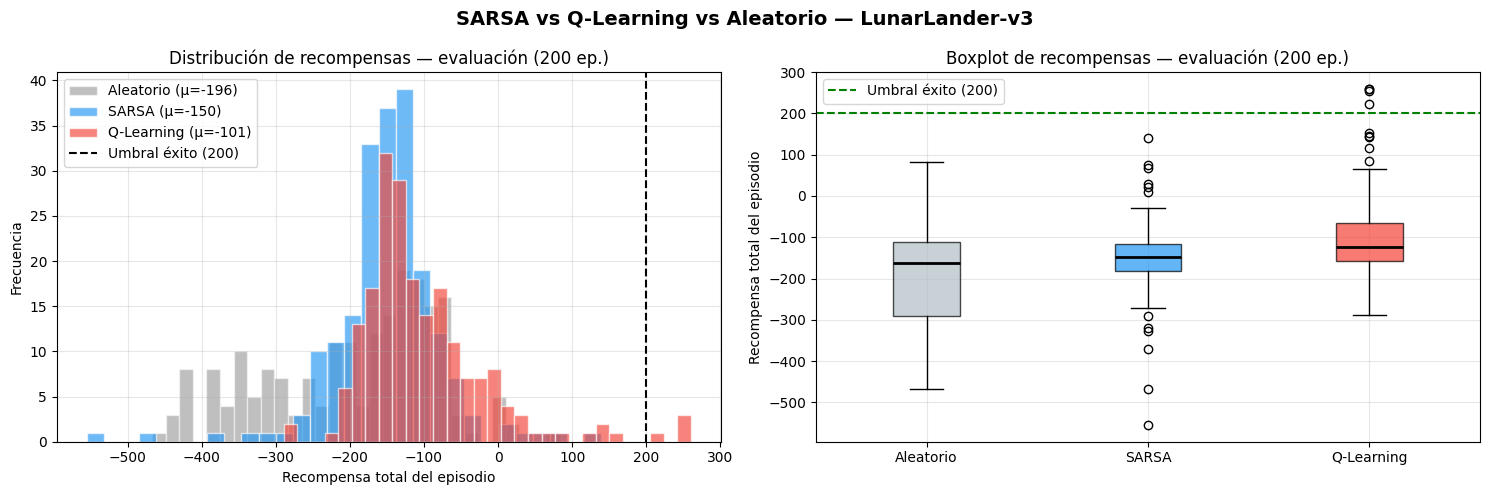

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ─── Histogramas superpuestos ─────────────────────────────────────────────────
ax = axes[0]
ax.hist(eval_random, bins=30, alpha=0.5, color="gray",     edgecolor="white",
        label=f"Aleatorio (μ={np.mean(eval_random):.0f})")
ax.hist(eval_sarsa,  bins=30, alpha=0.65, color=COLOR_SARSA, edgecolor="white",
        label=f"SARSA (μ={np.mean(eval_sarsa):.0f})")
ax.hist(eval_ql,     bins=30, alpha=0.65, color=COLOR_QL,    edgecolor="white",
        label=f"Q-Learning (μ={np.mean(eval_ql):.0f})")
ax.axvline(x=200, color="black", linestyle="--", linewidth=1.5, label="Umbral éxito (200)")
ax.set_xlabel("Recompensa total del episodio")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de recompensas — evaluación (200 ep.)")
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Boxplots ────────────────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(
    [eval_random, eval_sarsa, eval_ql],
    labels=["Aleatorio", "SARSA", "Q-Learning"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)
colors = ["#B0BEC5", COLOR_SARSA, COLOR_QL]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=200, color="green", linestyle="--", linewidth=1.5, label="Umbral éxito (200)")
ax.set_ylabel("Recompensa total del episodio")
ax.set_title("Boxplot de recompensas — evaluación (200 ep.)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("SARSA vs Q-Learning vs Aleatorio — LunarLander-v3", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Generación de Videos — SARSA y Q-Learning

Se graban episodios en modo **greedy puro** (ε = 0) para visualizar el comportamiento aprendido por cada algoritmo.

In [64]:
def record_episode(Q, filename, fps=30, seed=0, max_steps=1000):
    """
    Graba un episodio greedy y lo guarda como GIF animado.

    Args:
        Q:        Q-table aprendida
        filename: ruta de salida del GIF
        fps:      cuadros por segundo
        seed:     semilla del episodio
        max_steps: límite de seguridad

    Returns:
        total_reward: recompensa total obtenida
        filename:     ruta del GIF guardado
    """
    env_rec = gym.make("LunarLander-v3", render_mode="rgb_array")
    obs, _  = env_rec.reset(seed=seed)

    frames       = []
    total_reward = 0.0
    done         = False
    steps        = 0

    while not done and steps < max_steps:
        frame = env_rec.render()
        frames.append(frame)
        state  = discretize(obs)
        action = int(np.argmax(Q[state]))
        obs, r, terminated, truncated, _ = env_rec.step(action)
        done   = terminated or truncated
        total_reward += r
        steps += 1

    env_rec.close()
    imageio.mimsave(filename, frames, fps=fps, loop=0)
    return total_reward, filename


print("Grabando episodio SARSA...")
reward_sarsa_vid, gif_sarsa = record_episode(Q_sarsa, "lunarlander_sarsa.gif", fps=30, seed=410)
print(f"  Recompensa: {reward_sarsa_vid:.1f}  →  {gif_sarsa}")

print("Grabando episodio Q-Learning...")
reward_ql_vid, gif_ql = record_episode(Q_ql, "lunarlander_qlearning.gif", fps=30, seed=410)
print(f"  Recompensa: {reward_ql_vid:.1f}  →  {gif_ql}")

Grabando episodio SARSA...
  Recompensa: -134.2  →  lunarlander_sarsa.gif
Grabando episodio Q-Learning...
  Recompensa: -92.6  →  lunarlander_qlearning.gif


### 9.1 Video del agente SARSA

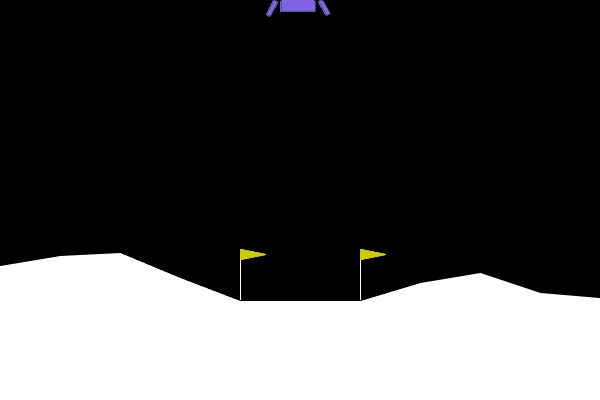

In [65]:
IPImage(filename="lunarlander_sarsa.gif", width=550)

### 9.2 Video del agente Q-Learning

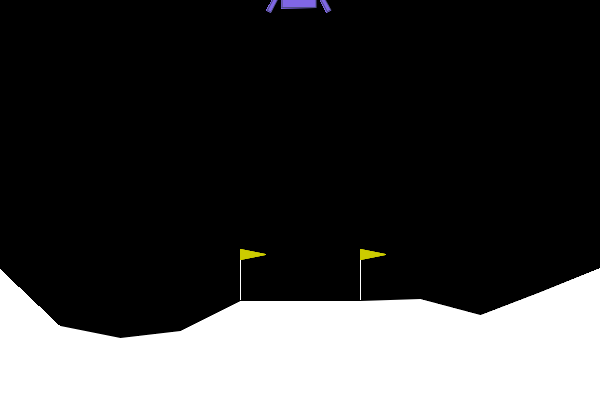

In [56]:
IPImage(filename="lunarlander_qlearning.gif", width=550)